<a href="https://colab.research.google.com/github/apester/TDA/blob/main/TDA_Lecture_2_Exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 2 Exercises — Core Concepts of TDA

This notebook is a student exercise companion for Lecture 2.
Work through the tasks and complete the missing code or written answers.


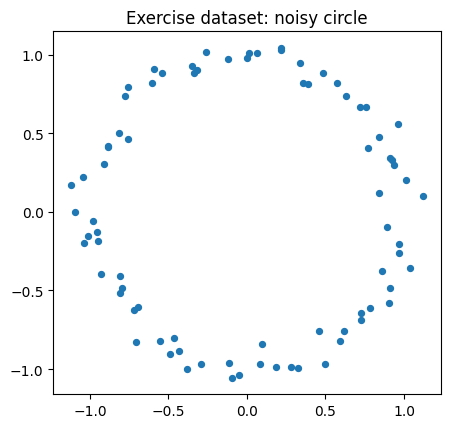

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

def make_noisy_circle(n=80, radius=1.0, noise=0.06, seed=3):
    rng = np.random.default_rng(seed)
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    x = radius*np.cos(theta) + rng.normal(0, noise, n)
    y = radius*np.sin(theta) + rng.normal(0, noise, n)
    return np.column_stack([x, y])

def pairwise_distances(X):
    X = np.asarray(X)
    n = len(X)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            d = np.linalg.norm(X[i] - X[j])
            D[i, j] = D[j, i] = d
    return D

def rips_edges(X, eps):
    D = pairwise_distances(X)
    edges = []
    for i in range(len(X)):
        for j in range(i+1, len(X)):
            if D[i, j] <= eps:
                edges.append((i, j))
    return edges

def rips_triangles(X, eps):
    edges = set(tuple(sorted(e)) for e in rips_edges(X, eps))
    triangles = []
    for i, j, k in combinations(range(len(X)), 3):
        if ((i, j) in edges) and ((i, k) in edges) and ((j, k) in edges):
            triangles.append((i, j, k))
    return triangles

def plot_rips_2d(X, eps, show_triangles=False):
    plt.figure(figsize=(5,5))
    plt.scatter(X[:,0], X[:,1], s=25, zorder=3)
    for i, j in rips_edges(X, eps):
        plt.plot([X[i,0], X[j,0]], [X[i,1], X[j,1]], lw=1, zorder=2)
    if show_triangles:
        for i, j, k in rips_triangles(X, eps):
            tri = np.array([X[i], X[j], X[k]])
            plt.fill(tri[:,0], tri[:,1], alpha=0.15, zorder=1)
    plt.gca().set_aspect('equal')
    plt.title(f"Rips complex at eps={eps:.2f}")
    plt.show()

X = make_noisy_circle()
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], s=18)
plt.gca().set_aspect('equal')
plt.title("Exercise dataset: noisy circle")
plt.show()


## Exercise 1 — Metric intuition

Explain in your own words:

1. Why does TDA need a metric or similarity notion?
2. Give one example where Euclidean distance is reasonable.
3. Give one example where cosine distance may be better.


## Exercise 2 — Rips complex at different scales

Run the next cell for three values of `eps`.  
Then answer:

- At which scale do you first start seeing a loop-like structure?
- At which scale do triangles begin to fill that loop?


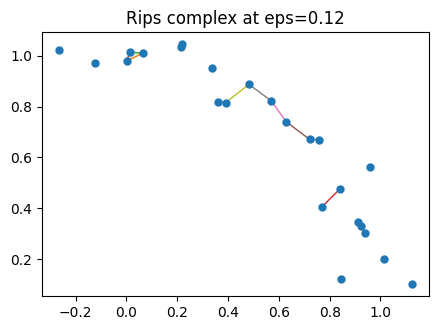

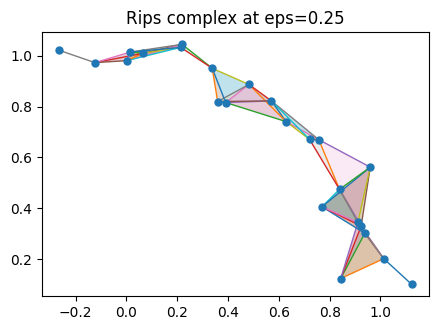

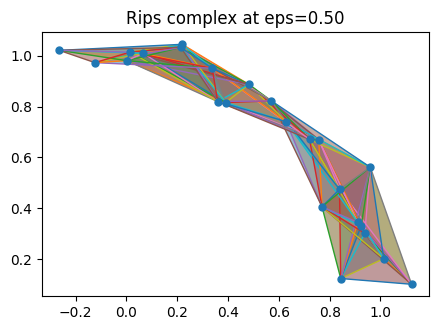

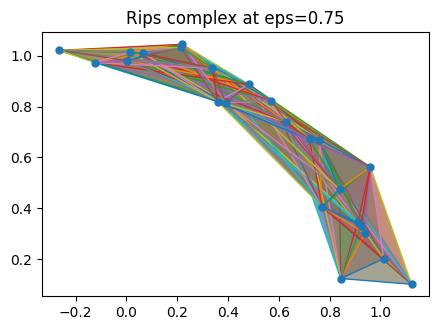

In [8]:
for eps in [0.12, 0.25, 0.50, 0.75]:
    plot_rips_2d(X[:24], eps=eps, show_triangles=True)


## Exercise 3 — Count edges and triangles

Complete the code to count how many edges and triangles exist at a given scale.


In [3]:
eps = 0.25

# TODO: replace the question marks
num_edges = len(rips_edges(X[:24], eps))
num_triangles = len(rips_triangles(X[:24], eps))

print("edges =", num_edges)
print("triangles =", num_triangles)


edges = 58
triangles = 55


## Exercise 4 — Connected components

Complete the union-find based function and track the approximate value of \(\beta_0\) across scale.


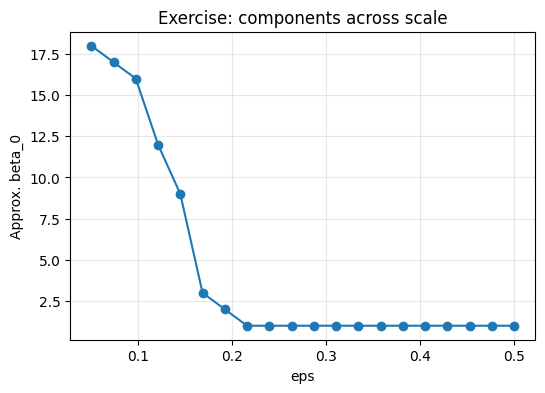

In [4]:
def components_from_edges(n, edges):
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for a, b in edges:
        union(a, b)

    roots = {find(i) for i in range(n)}
    return len(roots)

eps_grid = np.linspace(0.05, 0.5, 20)
beta0 = [components_from_edges(len(X[:24]), rips_edges(X[:24], eps)) for eps in eps_grid]

plt.figure(figsize=(6,4))
plt.plot(eps_grid, beta0, marker="o")
plt.xlabel("eps")
plt.ylabel("Approx. beta_0")
plt.title("Exercise: components across scale")
plt.grid(True, alpha=0.3)
plt.show()


## Exercise 5 — Concept questions

Answer briefly:

1. What is the difference between a cycle and a boundary?
2. Why is a filled triangle not evidence of an \(H_1\) hole?
3. In a persistence diagram, what do points close to the diagonal usually indicate?
4. Why is persistence often more informative than topology at a single scale?


## Exercise 6 — Optional with `ripser`

If you have `ripser` installed, compute the persistence diagram for the noisy circle.
Then describe the most prominent topological feature you observe.


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.4 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=c5bd0197e62cebbd49472bc3b816206a7cbe303cf51e7d4f814434b77d2fba3b
  Stored in directory: /root/.cache/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp


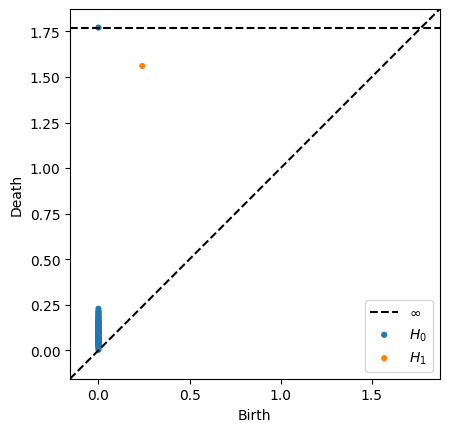

In [6]:
!pip install Cython
!pip install Ripser
try:
    from ripser import ripser
    from persim import plot_diagrams

    result = ripser(X, maxdim=1)
    diagrams = result["dgms"]
    plot_diagrams(diagrams, show=True)
except Exception as e:
    print("Optional section skipped.")
    print("Reason:", e)


## Mini takeaway

A good verbal summary for this lecture is:

> Start with data and a distance, build complexes across scale, and interpret the features that persist.
